# Introduction

In this lab, you’ll work with eye-tracking data to learn how to process, clean, and analyze eye movement signals.

We’ll start by exploring the raw data and metadata, then move on to signal cleaning—removing blinks, preserving fixations, and visualizing gaze points. Finally, you’ll compute basic statistics and compare eye movement patterns across subjects.

This exercise will give you hands-on experience with practical techniques used in eye-tracking analysis, especially in the context of ophthalmological MRI studies.

Let’s begin by setting up the environment and inspecting the data!

# Step 0: Preparing the env needed in this exercise

In [ ]:
%cd /content/
%mkdir siginf_0416
%cd /content/siginf_0416/
! pip install ppjson numpy pandas matplotlib seaborn
! git clone https://github.com/MattechLab/SigInf_2025.git

!pwd
!ls




/content/sunday
Cloning into 'SigInf_2025'...
remote: Enumerating objects: 395, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 395 (delta 2), reused 8 (delta 2), pack-reused 385 (from 1)
Receiving objects: 100% (395/395), 230.63 MiB | 31.59 MiB/s, done.
Resolving deltas: 100% (104/104), done.
Updating files: 100% (211/211), done.
/content/sunday
SigInf_2025
/content/SigInf_2025/9-et-data-processing


In [ ]:
%cd /content/siginf_0416/SigInf_2025/9-et-data-processing/
! ls

/content/sunday/SigInf_2025/9-et-data-processing
data		   L9_eye-tracking_data_Task.ipynb  plot.py
eyetrackingrun.py  mask_gen.py			    ppjson.py


In [ ]:
# Derived from:
# https://www.axonlab.org/hcph-sops/data-management/eyetrack-qc
# Load the autoreload extension
%load_ext autoreload
# Set autoreload to update the modules every time before executing a new line of code
%autoreload 2

%matplotlib inline
from pathlib import Path
import json
import ppjson
from importlib import reload  # For debugging purposes

import numpy as np
import pandas as pd

import eyetrackingrun as et
import plot_heat

from IPython.display import HTML
from matplotlib import animation
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import copy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Step 1: Inspecting Eye-Tracking Data

In this step, we’ll begin by parsing the metadata of our eye-tracking data. This will help us understand the structure of the data, including the recording parameters, subject details, and any relevant events or labels. Parsing the metadata provides insight into the conditions and settings during data collection, which is essential for accurate analysis.


In [9]:
# Specify the subject and modality you want to inspect
# Here we take subject 1 and T1w as example

subject_idx = 1
T_idx = 1

if T_idx == 1:
    mode = 'T1'
else:
    mode = 'T2'


BIDS_PATH = Path("./data/")  # file within a subdirectory
FILE_NAME = f"sub00{subject_idx}_T{T_idx}"

# session = "001" #can be a string to be defined when required
tsv_name = f"{FILE_NAME}.tsv.gz"

recording_file = BIDS_PATH / tsv_name
print(f'recording_file: {recording_file}')

recording = pd.read_csv(
    recording_file,
    sep="\t",
    na_values="n/a",
)

recording_file: data/sub001_T1.tsv.gz


This command shows the first few rows of our eye-tracking dataset,
helping us understand the organization, key columns, and the format of the data.
This step is useful to verify that the data loaded correctly and to identify any initial patterns or anomalies.

In [10]:
recording.head()

,Unnamed: 0,eye1_x_coordinate,eye1_y_coordinate,eye1_pupil_size,eye1_pupil_x_coordinate,eye1_pupil_y_coordinate,eye1_href_x_coordinate,eye1_href_y_coordinate,fast_raw_x_velocity,screen_ppdeg_x_coordinate,screen_ppdeg_y_coordinate,timestamp,eye1_fixation,eye1_saccade,eye1_blink
0,0,599.799988,440.299988,2721.0,1126.0,-4793.0,1972.0,1384.0,4.591214e-41,27.1,26.9,1084634,0,0,0
1,1,600.000000,441.299988,2718.0,1129.0,-4782.0,1974.0,1394.0,4.591214e-41,27.1,26.9,1084635,0,0,0
2,2,600.700012,442.399994,2716.0,1138.0,-4769.0,1981.0,1405.0,4.591214e-41,27.1,26.9,1084636,0,0,0
3,3,601.400024,442.700012,2709.0,1147.0,-4766.0,1988.0,1408.0,4.591214e-41,27.1,26.9,1084637,0,0,0
4,4,601.799988,443.000000,2704.0,1152.0,-4762.0,1991.0,1411.0,4.591214e-41,27.1,26.9,1084638,0,0,0


In [11]:
print(f'The length of the recording: {len(recording)}')

The length of the recording: 754932


# Step 2: Understanding Metadata

The metadata provides crucial information about the setup and parameters used during eye-tracking data collection. By examining the metadata, we can gain insights into the recording conditions, data quality, and calibration settings.


In [12]:
metadata = json.loads((
    recording_file.parent
    / recording_file.name.replace(".tsv.gz", ".json")
).read_text())

metadata

{'AverageCalibrationError': [0.5],
 'CalibrationCount': 1,
 'CalibrationLog': [[1047679,
   '>>>>>>> CALIBRATION (HV5,P-CR) FOR RIGHT: <<<<<<<<<'],
  [1047679, 'Calibration points:'],
  [1047680, '-10.3, -50.9         0,      0'],
  [1047680, '-8.9, -71.9         0,  -2457'],
  [1047680, '-9.3, -29.2         0,   2457'],
  [1047680, '-41.2, -50.5     -3474,      0'],
  [1047680, '24.2, -49.8      3474,      0'],
  [1047680, 'eye check box: (L,R,T,B)\n\t  -48    31   -76   -25'],
  [1047680, 'href cal range: (L,R,T,B)\n\t-5211  5211 -3686  3686'],
  [1047680,
   'Cal coeff:(X=a+bx+cy+dxx+eyy,Y=f+gx+goaly+ixx+jyy)\n   5.882e-05  107.02  1.2434 -0.18295 -0.27969 \n   4.4115e-05 -0.84952  115.02 -0.085003 -0.090966'],
  [1047680, 'Prenormalize: offx, offy = -10.326 -50.929'],
  [1047680, 'Gains: cx:102.441 lx:116.794 rx:88.586'],
  [1047680, 'Gains: cy:109.181 ty:118.022 by:110.039'],
  [1047680, 'Resolution (upd) at screen center: X=2.6, Y=2.4'],
  [1047680, 'Gain Change Proportion: X: 0.

For instance:
- **RecordedEye**: This specifies which eye was tracked. Here, the data corresponds to the right eye.
- **SamplingFrequency**: The sampling rate is 1000 Hz (1 kHz), meaning the data captures 1000 samples per second.
- **CalibrationDetails**: We can see the calibration method used (`HV5`), calibration quality (`GOOD`), and errors.

Understanding these parameters helps us ensure data reliability and assess the quality of eye-tracking measurements before analysis.

In [13]:
# Prepare the time axis based on the sampling frequency

t_axis = (
    recording.timestamp.values - recording.timestamp[0]
) / metadata["SamplingFrequency"]
print(f"The end of the timestamp: {t_axis[-1]}")

The end of the timestamp: 754.931


In this excercise, we will be interested in: eye1_x_coordinate, eye1_y_coordinate, timestamp, eye1_fixation, eye1_saccade, eye1_blink, eye1_pupil_size.

In [14]:
# We can change the naming of each column to make it more readable
recording = recording.rename(
        columns={
            f"eye1_pupil_size": f"pupil_size",
            f"eye1_fixation": f"fixation",
            f"eye1_saccade": f"saccade",
            f"eye1_blink": f"blink",
            f"eye1_x_coordinate": f"x_coordinate",
            f"eye1_y_coordinate": f"y_coordinate"
        }
    )

metadata["Columns"] = recording.columns.tolist()

In [15]:
metadata["Columns"]

['Unnamed: 0',
 'x_coordinate',
 'y_coordinate',
 'pupil_size',
 'eye1_pupil_x_coordinate',
 'eye1_pupil_y_coordinate',
 'eye1_href_x_coordinate',
 'eye1_href_y_coordinate',
 'fast_raw_x_velocity',
 'screen_ppdeg_x_coordinate',
 'screen_ppdeg_y_coordinate',
 'timestamp',
 'fixation',
 'saccade',
 'blink']

# Step 3: Inspecting Signals, Event Masks and Correlation
In this step we first visualize all the signals in the recordings to examine the overall shapes (trend, variability, or periodicity) and the scale of its values (range and units).

Besides, eye-tracking data includes event masks, which label segments of the data corresponding to specific events such as blinks, saccades, or fixations. These masks are typically binary arrays or categorical labels indicating the presence of a specific event at each timestamp.

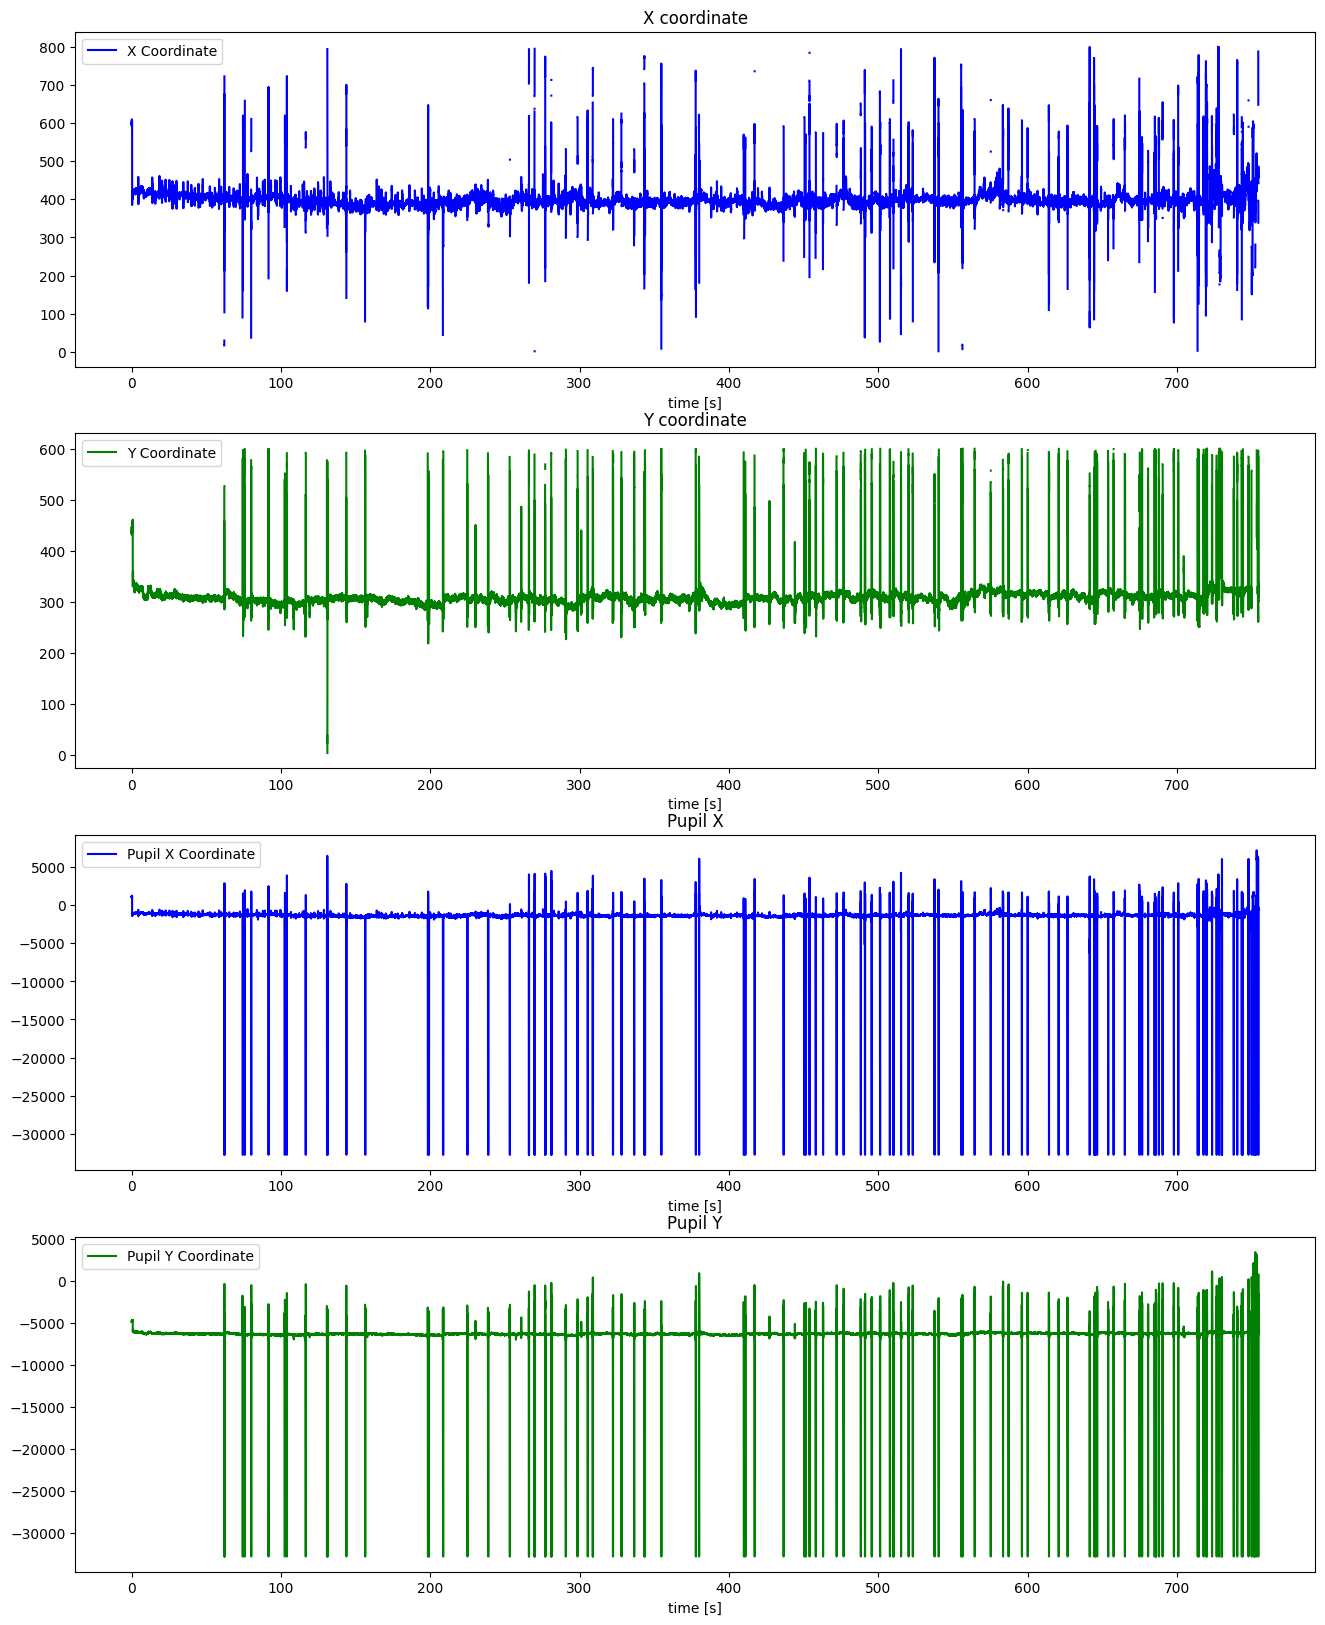

In [16]:
# Your turn here :)
# Could you plot the columns of recordings below:
# "x_coordinate", "y_coordinate", "eye1_pupil_x_coordinate", "eye1_pupil_y_coordinate"

check_all = True
if check_all:
    fig,axes = plt.subplots(4, 1, figsize=(16, 20), sharex=False)

    # Example: Plot x coordinate
    # axes[0].plot(t_axis, recording["x_coordinate"].values, label='X Coordinate', color='blue')
    # axes[0].set_title("X coordinate")
    # axes[0].legend()
    # axes[0].set_xlabel("time [s]")

    # Plot y coordinate
    # axes[1].plot(...)

    # Plot pupil x coordinate
    # axes[2].plot(...)

    # Plot pupil y coordinate
    # axes[3].plot(...)

    #----Cut from here----------------------------
    # Example: Plot x coordinate
    axes[0].plot(t_axis, recording["x_coordinate"].values, label='X Coordinate', color='blue')
    axes[0].set_title("X coordinate")
    axes[0].legend()
    axes[0].set_xlabel("time [s]")
    # Plot y coordinate
    axes[1].plot(t_axis, recording["y_coordinate"].values, label='Y Coordinate', color='green')
    axes[1].set_title("Y coordinate")
    axes[1].legend()
    axes[1].set_xlabel("time [s]")

    # Plot pupil x coordinate
    axes[2].plot(t_axis, recording["eye1_pupil_x_coordinate"].values, label='Pupil X Coordinate', color='blue')
    axes[2].set_title("Pupil X")
    axes[2].legend()
    axes[2].set_xlabel("time [s]")

    # Plot pupil y coordinate
    axes[3].plot(t_axis, recording["eye1_pupil_y_coordinate"].values, label='Pupil Y Coordinate', color='green')
    axes[3].set_title("Pupil Y")
    axes[3].legend()
    axes[3].set_xlabel("time [s]")
     #----End here----------------------------






Here we check the pupil size

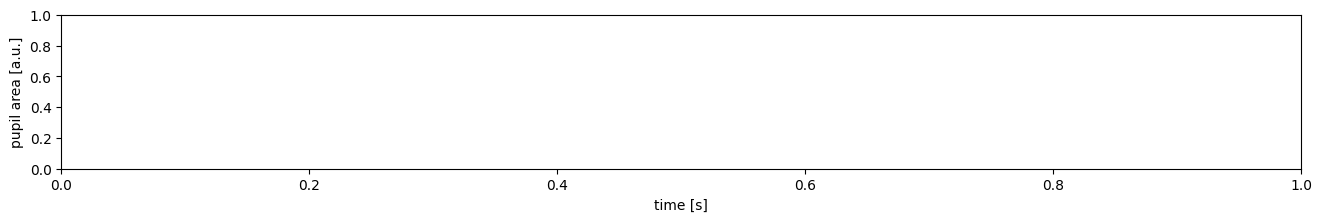

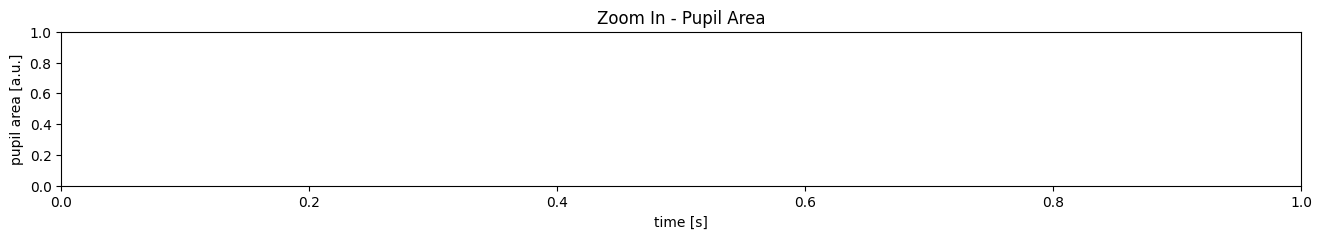

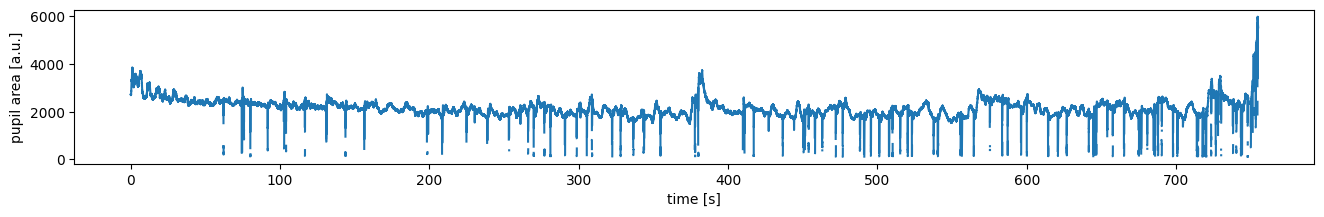

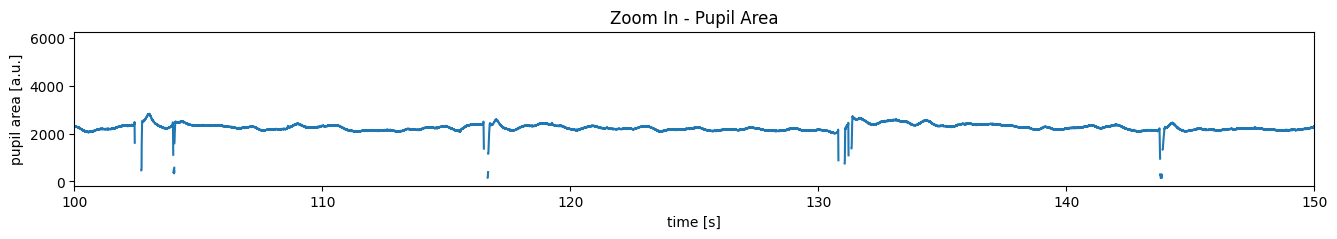

In [17]:
# 🔍 Your turn!
# Plot the "pupil_size" signal from the recordings.
# 👉 Use the same plotting approach as in the previous example.


check_pupil = True
check_zoom_in = True

if check_pupil:
    fig = plt.figure(figsize=(16, 2))
    # plt.plot(...)
    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]");

# 🔍 Your turn!
# Do you notice any discontinuities in the waveform?
# 👉 Try zooming in on the time range between 100 and 150 to investigate more closely.
# What do you observe in that segment?

if check_zoom_in:
    fig = plt.figure(figsize=(16, 2))
    # plt.plot(...)
    plt.title("Zoom In - Pupil Area")
    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]")




#----Cut from here----------------------------
if check_pupil:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["pupil_size"].values,
    )

    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]");

if check_zoom_in:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["pupil_size"].values,
    )
    plt.title("Zoom In - Pupil Area")
    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]")

    plt.xlim((100, 150))
#----End here----------------------------

Check the eye events:

 - Blink
    
- Saccade
    
- Fixation


We want to first check the masks of each event and want to inspect the correlation with the signals we checked above.



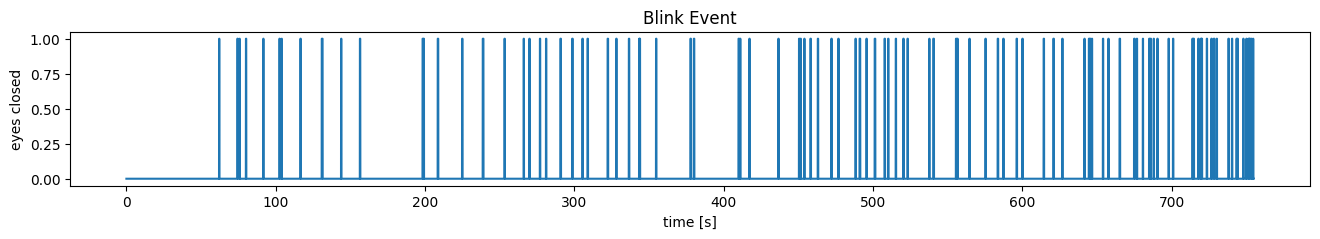

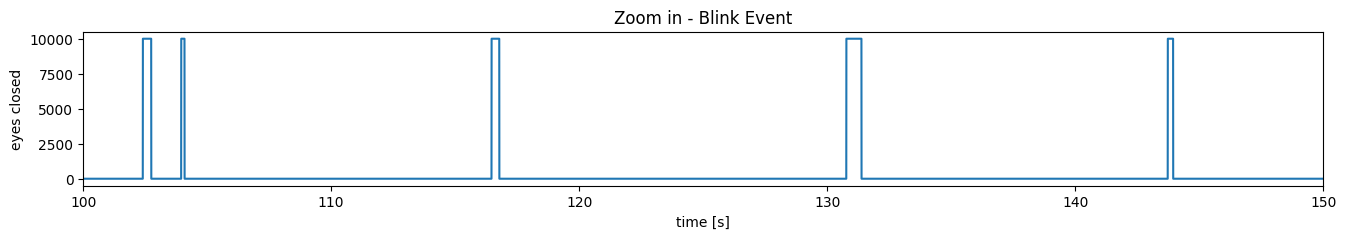

In [18]:
# Check blinking and zoom in to a smaller range
check_blink = True
check_blink_zoom_in = True

if check_blink:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["blink"].values,
    )
    plt.title("Blink Event")
    plt.xlabel("time [s]")
    plt.ylabel("eyes closed");

if check_blink_zoom_in:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["blink"].values * 10000,
    )
    plt.xlabel("time [s]")
    plt.ylabel("eyes closed")
    plt.title("Zoom in - Blink Event")
    plt.xlim((100, 150))

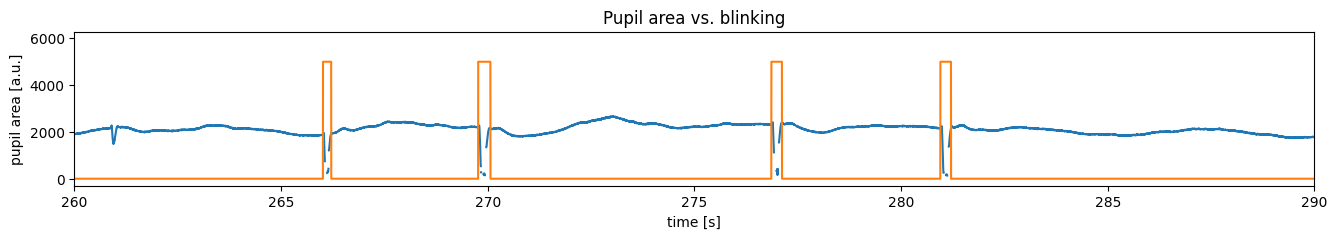

In [19]:
# 🔍 Your turn!
# Try plotting the "pupil_size" signal together with the "blink" signal.
# Tip: Overlay them in the same figure to observe their relationship over time.
# 👉 Does the visualization make sense? What do you notice about pupil size during blinks?

#  #----Cut from here----------------------------
plot_pupil_blink = True
if plot_pupil_blink:
    fig = plt.figure(figsize=(16, 2))

    plt.plot(
        t_axis,
        recording["pupil_size"].values,
    )

    plt.plot(
        t_axis,
        recording["blink"].values * 5000,
    )


    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]")
    plt.xlim((260, 290))
    plt.title('Pupil area vs. blinking')

 #----End here----------------------------

Check saccading

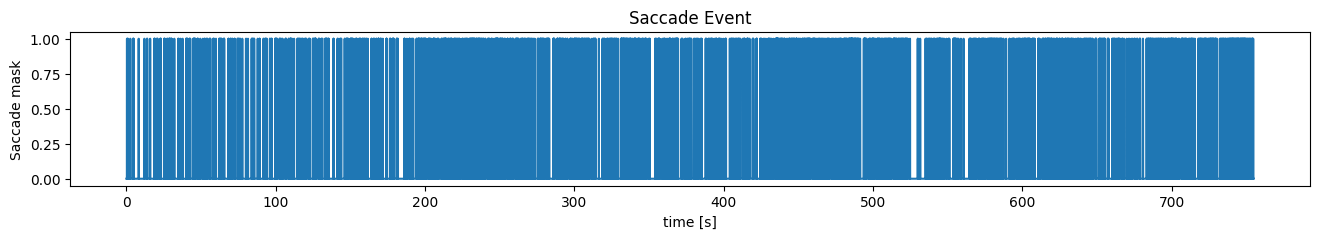

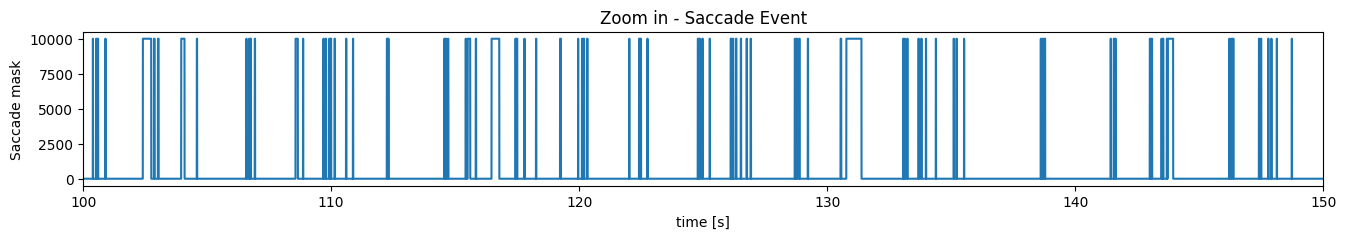

In [20]:
# 🔍 Your turn!
# Check the saccades in the data.
# 👉 Try zooming in on a smaller time range to analyze the movement in greater detail.

# ---cut from here---
Check_saccading=True
if Check_saccading:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["saccade"].values,
    )
    plt.title("Saccade Event")
    plt.xlabel("time [s]")
    plt.ylabel("Saccade mask");

    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["saccade"].values * 10000,
    )
    plt.xlabel("time [s]")
    plt.ylabel("Saccade mask");
    plt.title("Zoom in - Saccade Event")
    plt.xlim((100, 150))
  # ---end cut---

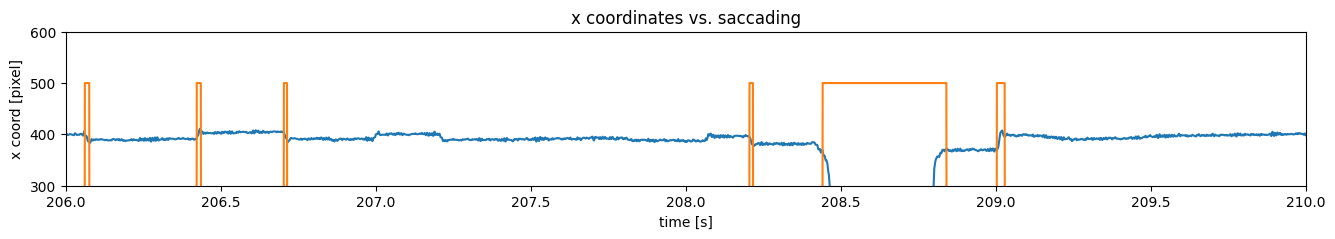

In [21]:
# 🔍 Your turn!
# Try plotting the "x_coordinate" signal together with the "saccade" signal.
# Tip: Overlay them in the same figure to observe their relationship over time.
# 👉 Does the visualization make sense? What do you notice about x coordinates during saccade?

#---cut from here------------

plot_pupil_saccade = True

if plot_pupil_saccade:
    fig = plt.figure(figsize=(16, 2))

    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["saccade"].values * 500,
    )

    plt.xlabel("time [s]")
    plt.ylabel("x coord [pixel]")
    plt.xlim((206, 210))
    plt.ylim((300, 600))
    plt.title('x coordinates vs. saccading')
# -------end-----------------------------

Check fixation

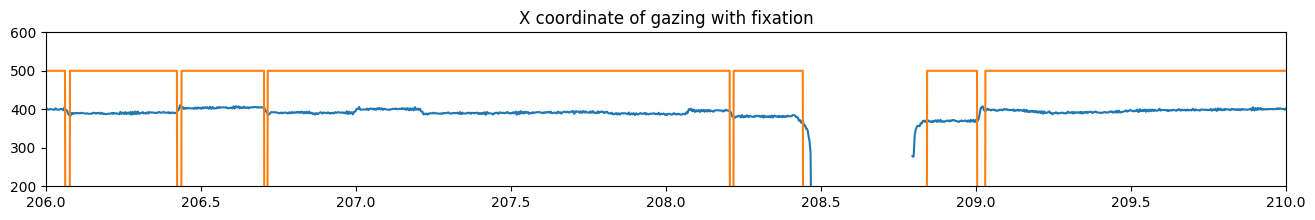

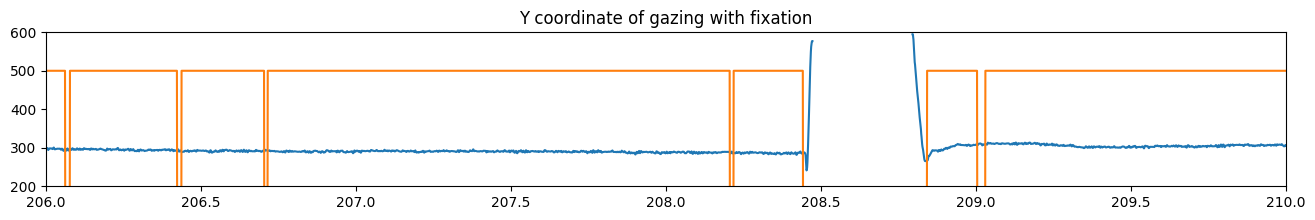

In [22]:
# 🔍 Your turn!
# Try plotting the "x_coordinate" signal together with the "fixation" signal.
# Try plotting the "y_coordinate" signal together with the "fixation" signal.
# Tip: Overlay them in the same figure to observe their relationship over time.
# 👉 Does the visualization make sense? What do you notice about x/y coordinates during fixation?

#---cut from here------------
plot_fixation = True
xlim = (206, 210)
ylim = (200, 600)

if plot_fixation:
    # Fixation
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('X coordinate of gazing with fixation')

    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["y_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('Y coordinate of gazing with fixation')
    # -------end-----------------------------

Did you find the correlation between x/y coordinates, pupil area and saccade or fixation events?


# Step 4: Data Cleaning

- Extract the signals we need

- Eliminate the blinking and non-fixation area of ET data.
- Design some criteria for preserving the useful data


## 4.1: Extract the signals we need

In this exercise, we are focusing on a subset of the eye-tracking (ET) data. Specifically, we will process the first portion of the ET data, which corresponds to the duration of the sequence `T1_LIBRE`.


We will extract the first portion of the data with a length matching `T1_LIBRE`.
Inspect the extracted subset to understand its structure and characteristics, such as gaze coordinates and event markers.

In [23]:
# Here is the given information: time duration (in sec) according to the prior information.
# Please do not change the values in this block

if  subject_idx == 1:
    T1_LIBRE = 374.558
elif subject_idx == 2:
    T1_LIBRE = 374.380
elif subject_idx == 3:
    T1_LIBRE = 334.237
else:
    T1_LIBRE = 374.565



print(f"The length of T1_LIBRE Subject{subject_idx} should be: {T1_LIBRE}")



The length of T1_LIBRE Subject1 should be: 374.558


In [24]:
# We can extract the size of screen from metadata we observed before
size = (
    metadata["ScreenAOIDefinition"][1][1],
    metadata["ScreenAOIDefinition"][1][3],
)

# For easier processing the entire recording and only the coordinate
# We stored the (x,y) coordinate in the coor_data
# And stored the entire recording in the coor_recording
coor_data = recording[["x_coordinate", "y_coordinate"]]
print(f"Extract X Y coordinates from recording: {len(coor_data)}")

coor_recording = recording


coor_data.head()
# coor_recording.head()

Extract X Y coordinates from recording: 754932


,x_coordinate,y_coordinate
0,599.799988,440.299988
1,600.000000,441.299988
2,600.700012,442.399994
3,601.400024,442.700012
4,601.799988,443.000000


mode: T1
set start margin as 0
374558


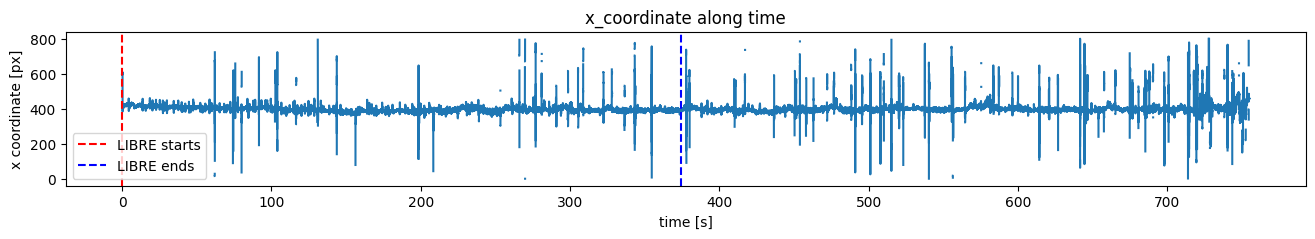

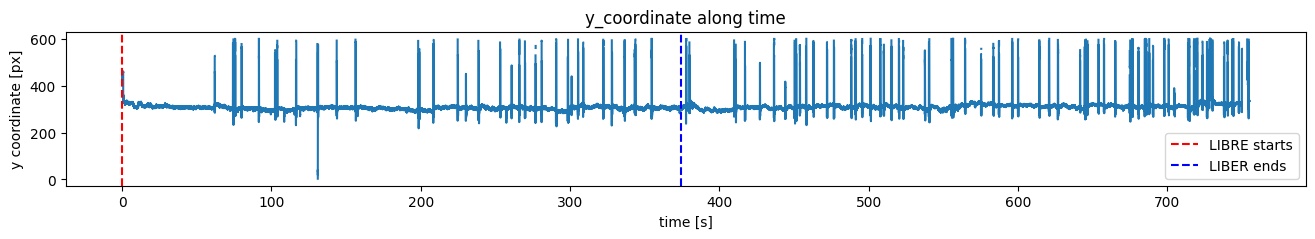

In [25]:
# start_margin determines where to begin extracting the useful portion of the eye-tracking (ET) data.
# In our case, it is set as 0.
# Please do not change the values in this block

start_margin = int(0.0*metadata['SamplingFrequency'])

print(f'mode: {mode}')
print(f"set start margin as {start_margin}")


T1_LIBRE_sample = T1_LIBRE*metadata['SamplingFrequency']



t_axis_xy = (
    coor_data.index
) / metadata["SamplingFrequency"]

# x coordinate
fig = plt.figure(figsize=(16, 2))

plt.plot(
    t_axis_xy,
    coor_data["x_coordinate"].values,
)


plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=(T1_LIBRE_sample+start_margin)/metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')


plt.title("x_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("x coordinate [px]")
plt.legend()

# y coordinate
fig = plt.figure(figsize=(16, 2))

plt.plot(
    t_axis_xy,
    coor_data["y_coordinate"].values,
)

plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=(T1_LIBRE_sample+start_margin)/ metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBER ends')



plt.title("y_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("y coordinate [px]")
plt.legend()

coor_data_LIBRE = coor_data[start_margin:int(T1_LIBRE_sample)]
coor_recording_LIBRE = coor_recording[start_margin:int(T1_LIBRE_sample)]

coor_data_LIBRE_raw = copy.deepcopy(coor_data_LIBRE)
print(len(coor_data_LIBRE))


## 4.2 Eliminating blinking

Based on the blink mask explored earlier, we now process the data to handle timestamps where blinks occurred. During a blink, gaze data is unreliable or missing, so we mark these periods by assigning NaN (Not a Number) to the gaze coordinates. \\
👉 Note: We do not remove the entire row of the dataframe; we use NaN as a placeholder for unreliable data during the blink period.


The data will be eliminated: 9513


<ipython-input-26-b10d4337cfbb>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan


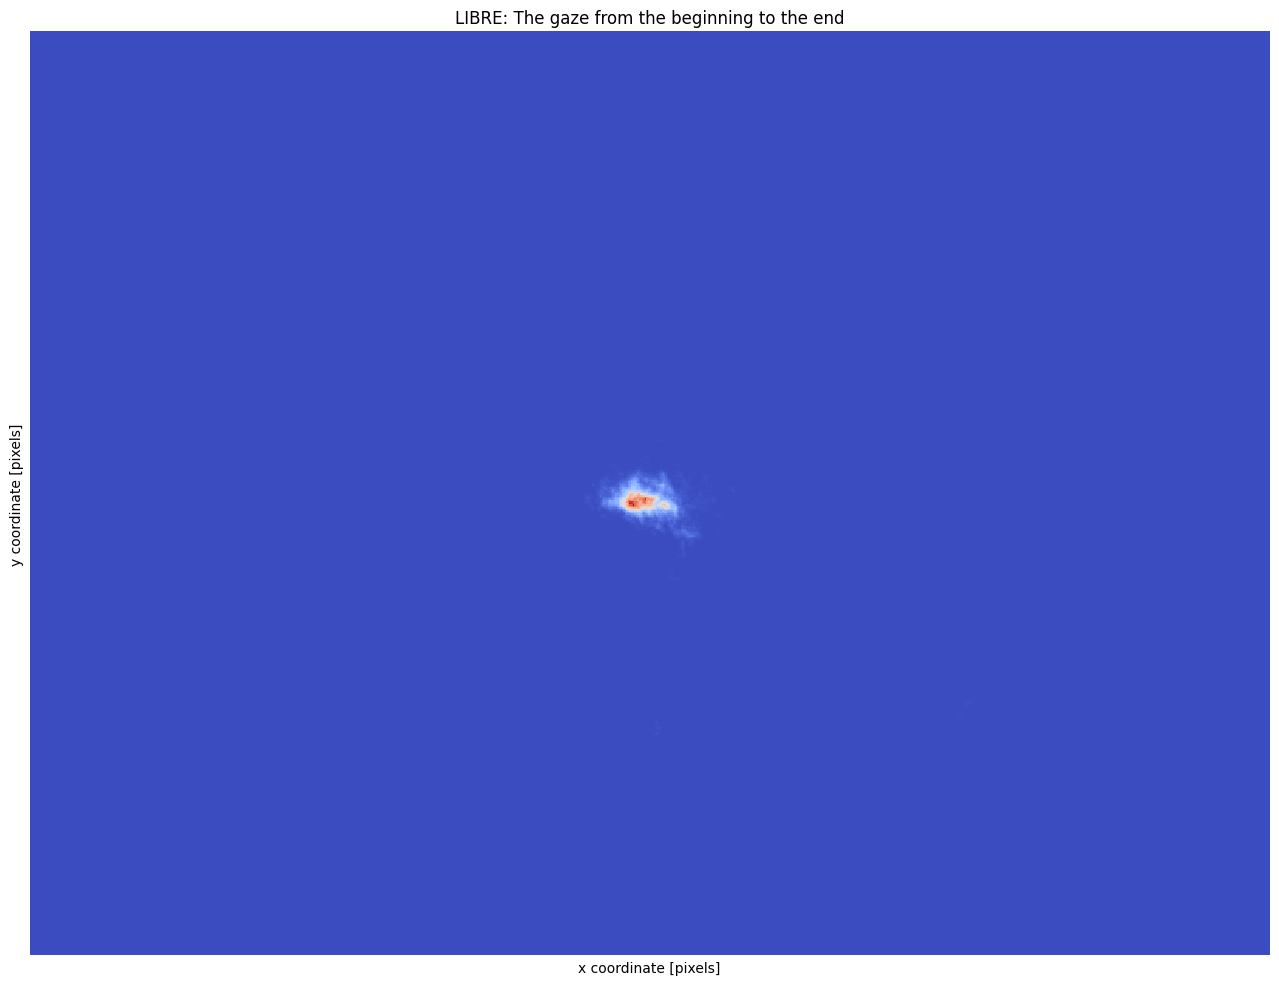

In [26]:

import plot_heat
use_eliminate_blink = True

def eliminate_blink(coor_data, coor_recording, seq_name):
  # 🔍 Your turn!
  # 👉 Try applying the blink mask to set these coordinates as NaN where blinks occurred.
  # How does this affect the dataset during the blink periods?

    # len_coord_blink = ???
    # print(f'The data will be eliminated: {len_coord_blink}')
    # coor_data = ???
    # coor_recording = ???

    return coor_data, coor_recording

# ----------cut-------------------
def eliminate_blink(coor_data, coor_recording, seq_name):
# Note: instead of filtering them out, I assign nan to the invalid elements to preserve the time information
    print(f'The data will be eliminated: {len(coor_data[coor_recording.blink > 0])}')
    coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan

    return coor_data, coor_recording
# ----------end-------------------


if use_eliminate_blink:
    coor_data_LIBRE,  coor_recording_LIBRE = eliminate_blink(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')

plot_heatmap = True
if plot_heatmap:

    plot_heat.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size,
                                 title='LIBRE: The gaze from the beginning to the end')




## 4.3 Preserving fixation

Similarly, we will preserve the timestamps where fixation events are detected.

The data will be eliminated: 21482


<ipython-input-27-c067bf40a70c>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coor_data.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan


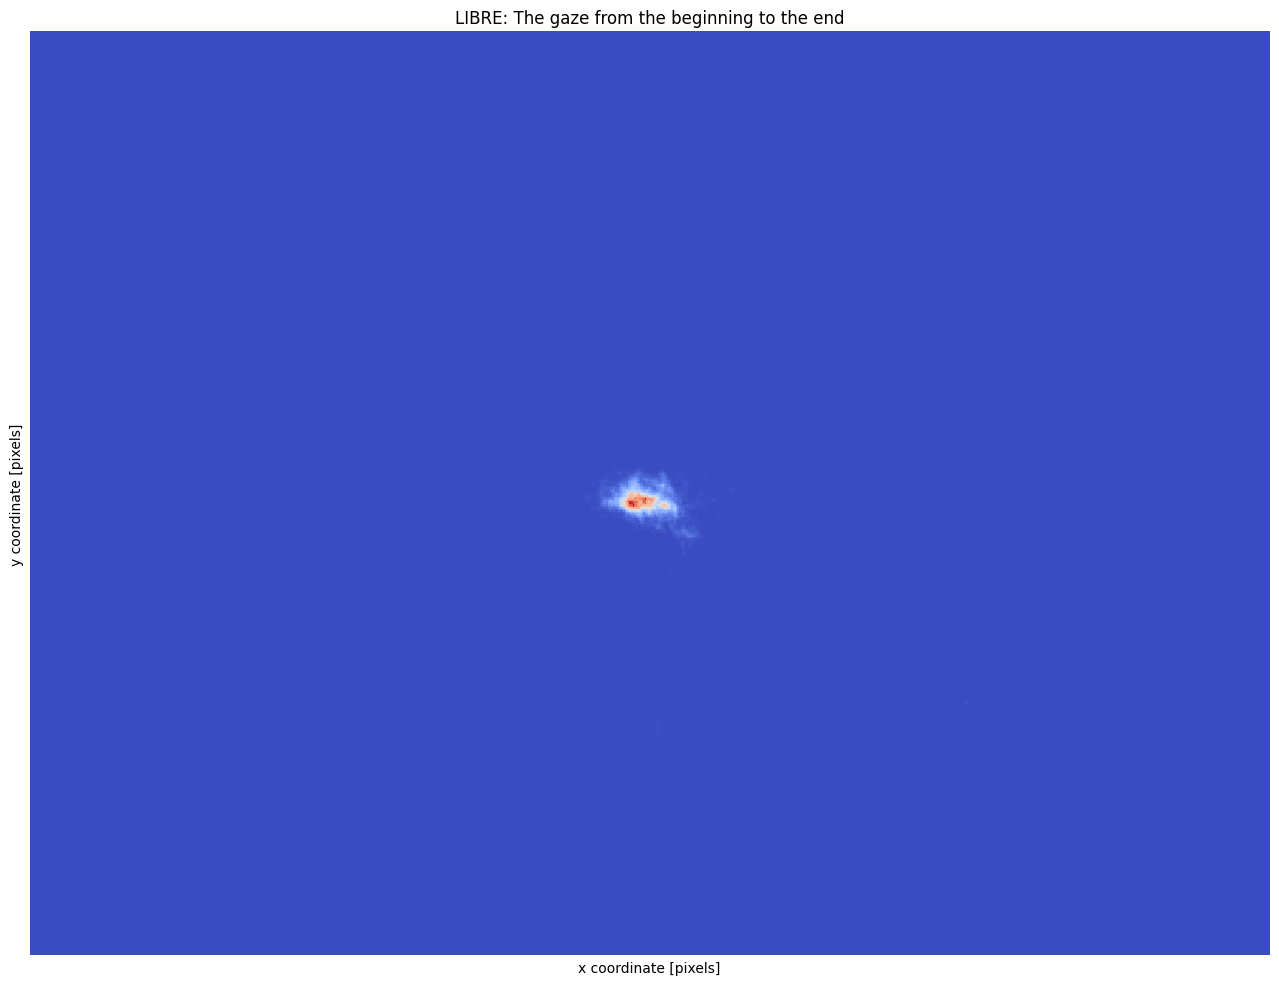

In [27]:
use_preserve_fixation = True

def preserve_fixation(coor_data, coor_recording, seq_name):
    # 🔍 Your turn!
    # 👉 Try applying the fixation mask to set these coordinates as NaN where non-fixation occurred.
    # How does this affect the dataset during the non-fixation periods?

    # len_coord_non_fixation =???
    # print(f'The data will be eliminated: {len_coord_non_fixation}')


    # Following the method above, how to filter the coor_data and coor_recording?
    # coor_data = ???
    # coor_recording = ???

    return coor_data, coor_recording
# ---------cut----------
def preserve_fixation(coor_data, coor_recording, seq_name):
#     coor_data = coor_data[coor_recording.fixation > 0]
#     coor_recording = coor_recording[coor_recording.fixation > 0]
    print(f'The data will be eliminated: {len(coor_data[coor_recording.fixation < 1])}')
    coor_data.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan

    return coor_data, coor_recording

# ------end-------------------------
if use_preserve_fixation:
    coor_data_LIBRE,  coor_recording_LIBRE = preserve_fixation(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')

plot_heatmap = True
if plot_heatmap:
    import plot
    plot_heat.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size,
                                 title='LIBRE: The gaze from the beginning to the end')


## 4.4 Plot the gazing dots

🎉 Congratulations! You have cleaned the data based on the mask of blinks and fixation.

To visualize the gaze points before/after the data cleaning, please simply run the cell below.

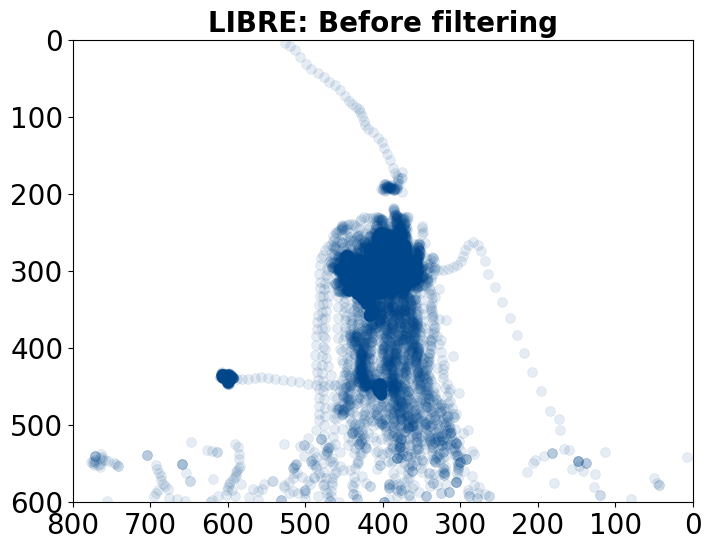

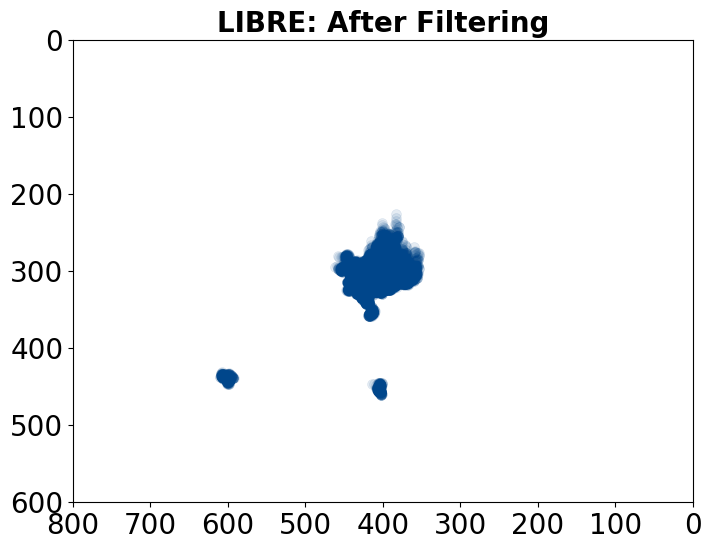

In [28]:
from matplotlib.font_manager import FontProperties
title_font = FontProperties(family='DejaVu Sans', size=20, weight='bold')
axis_font = FontProperties(family='DejaVu Sans', size=20)
# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE_raw['x_coordinate']
Y_coord = coor_data_LIBRE_raw['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: Before filtering', fontproperties=title_font)

for label in plt.gca().get_xticklabels():
    label.set_fontproperties(axis_font)

for label in plt.gca().get_yticklabels():
    label.set_fontproperties(axis_font)
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: After Filtering', fontproperties=title_font)

for label in plt.gca().get_xticklabels():
    label.set_fontproperties(axis_font)

for label in plt.gca().get_yticklabels():
    label.set_fontproperties(axis_font)
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
# ============================================================



## 4.5 Analyzing Gaze Point Distribution Before and After Filtering

After filtering out blink-related timestamps by assigning NaN to gaze coordinates, it's important to inspect how this operation has affected the distribution of gaze points along each dimension (e.g., x_coordinate and y_coordinate).

👉 To do this, you can use Kernel Density Estimation (KDE) to visualize the distribution of gaze points before and after filtering.

KDE is a non-parametric way to estimate the probability density function of a random variable.

It helps you see the concentration of data points in various regions of the gaze space, and how the removal of eye movement data affects the overall distribution.

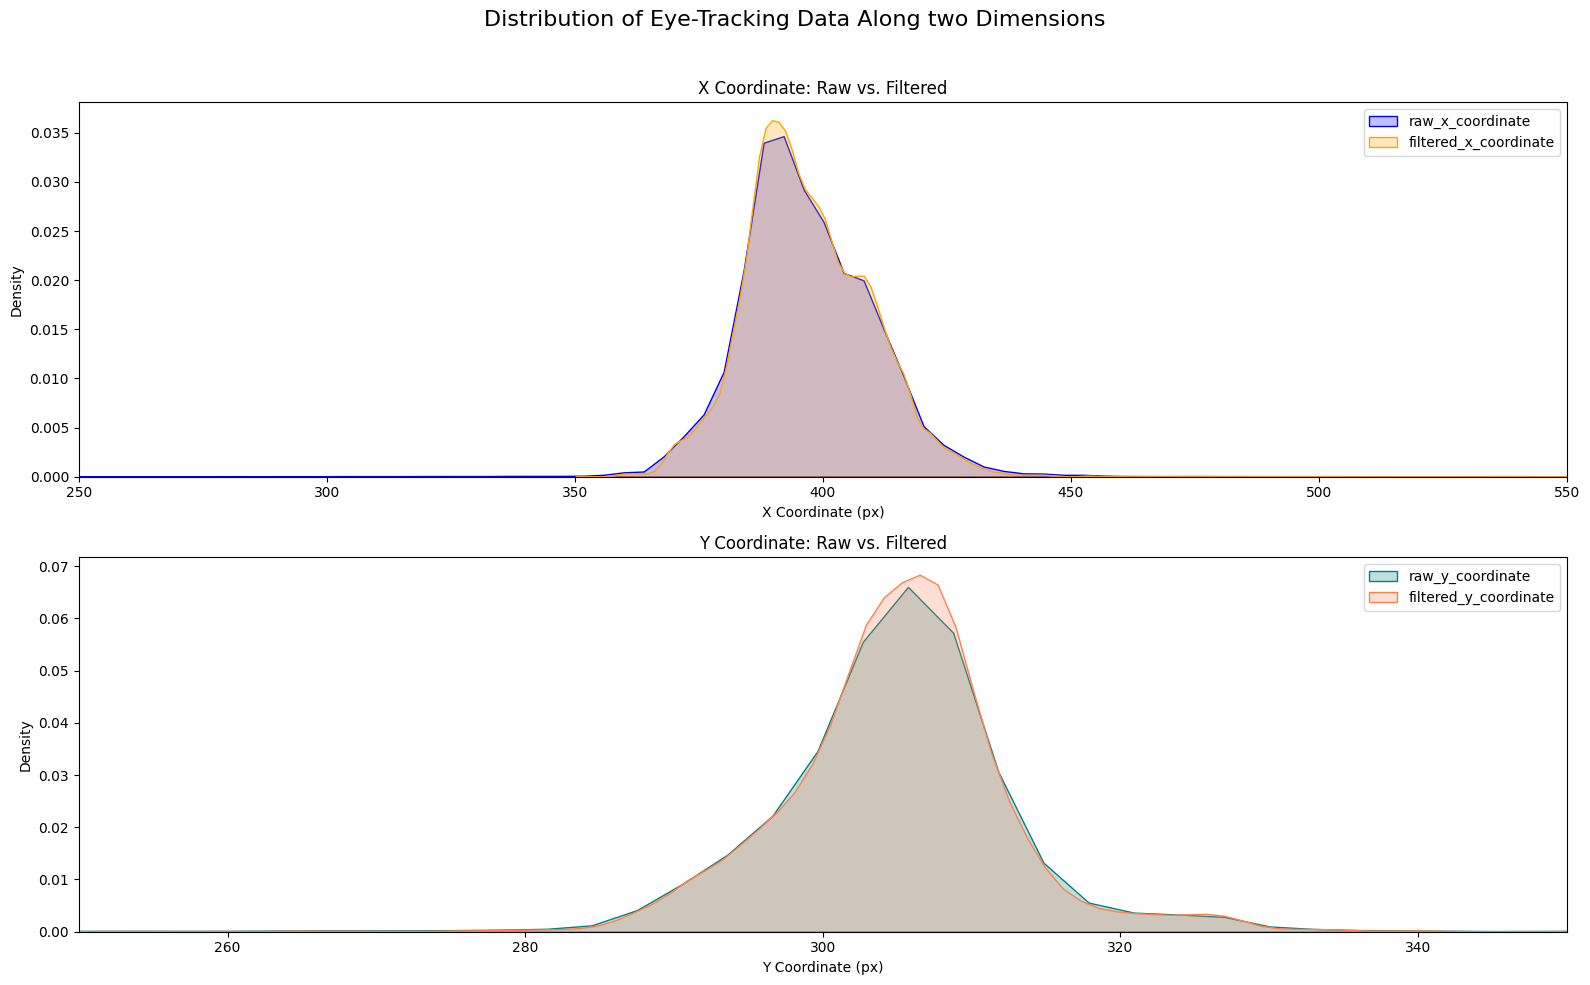

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot KDE for x_coordinate
sns.kdeplot(coor_data_LIBRE_raw['x_coordinate'].dropna(), ax=axes[0], color='blue', fill=True, label='raw_x_coordinate')
sns.kdeplot(coor_data_LIBRE['x_coordinate'].dropna(), ax=axes[0], color='orange', fill=True, label='filtered_x_coordinate')
axes[0].set_title("X Coordinate: Raw vs. Filtered")
axes[0].set_xlabel("X Coordinate (px)")
axes[0].set_ylabel("Density")
axes[0].set_xlim((250,550))
axes[0].legend()

# 🔍 Your turn!
# Plot the KDE for the y-coordinate as shown in the style above.
# axes[1]........
# 👉 Make sure to compare the distribution of the y-coordinate before and after filtering out blink-related data.
# How does the KDE change after cleaning the data?

# --------cut--------------------
sns.kdeplot(coor_data_LIBRE_raw["y_coordinate"].dropna(), ax=axes[1], color='teal', fill=True, label='raw_y_coordinate')
sns.kdeplot(coor_data_LIBRE["y_coordinate"].dropna(), ax=axes[1], color='coral', fill=True, label='filtered_y_coordinate')
axes[1].set_title("Y Coordinate: Raw vs. Filtered")
axes[1].set_xlabel("Y Coordinate (px)")
axes[1].set_ylabel("Density")
axes[1].set_xlim((250,350))
axes[1].legend()
# --------end---------------------
# Add the title
fig.suptitle("Distribution of Eye-Tracking Data Along two Dimensions", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Step 5: Calculate the mask, statistics

You can calculate the mask for preserving the ET data based on your needs.

In the following step, I will present my method to generate the mask according to the project I introduced in the course.

This will guide you in creating a mask specific to the requirements of the project and allow you to filter the data accordingly.

In [30]:
from mask_gen import cal_mask, plot_x_y_coord, filter_XY_coord

In [31]:
def cal_stats(coor_data):
    stats_dict = {}
    X_coord = coor_data["x_coordinate"].values
    Y_coord = coor_data["y_coordinate"].values

    # 🔍 Your turn!
    # Please finish the following codes to calculate the statistics of the gaze coordinates.
    # 👉 Note: some of the coordinates are NaNs! Make sure to handle NaN values properly when calculating the statistics.
    # You can use methods like `np.nanmean`, `np.nanstd`, etc., to ignore NaNs during the calculations. ChatGPT can help a lot :>

    # =================================================
    # stats_dict['x_mean'] =
    # stats_dict['x_median'] =       # Median, ignoring NaNs
    # stats_dict['x_std'] =        # Standard deviation
    # stats_dict['x_min'] =    # Minimum value
    # stats_dict['x_max'] =      # Maximum value
    # # Calculate 25th, 50th (median), and 75th percentiles while ignoring NaN values
    # stats_dict['x_q25'] =    # 25th percentile
    # stats_dict['x_q75'] =    # 75th percentile

    # stats_dict['y_mean'] =
    # stats_dict['y_median'] =      # Median, ignoring NaNs
    # stats_dict['y_std'] =         # Standard deviation
    # stats_dict['y_min'] =       # Minimum value
    # stats_dict['y_max'] =        # Maximum value
    # stats_dict['y_q25'] =    # 25th percentile
    # stats_dict['y_q75'] =    # 75th percentile

    return stats_dict


# -----cut------------------------
def cal_stats(coor_data):
    stats_dict = {}
    X_coord = coor_data["x_coordinate"].values
    Y_coord = coor_data["y_coordinate"].values

    stats_dict['x_mean'] = np.nanmean(X_coord)
    stats_dict['x_median'] = np.nanmedian(X_coord)      # Median, ignoring NaNs
    stats_dict['x_std'] = np.nanstd(X_coord)        # Standard deviation
    stats_dict['x_min'] = np.nanmin(X_coord)      # Minimum value
    stats_dict['x_max'] = np.nanmax(X_coord)      # Maximum value
    # Calculate 25th, 50th (median), and 75th percentiles while ignoring NaN values
    stats_dict['x_q25'] = np.nanpercentile(X_coord, 25)  # 25th percentile
    stats_dict['x_q75'] = np.nanpercentile(X_coord, 75)  # 75th percentile

    stats_dict['y_mean'] = np.nanmean(Y_coord)
    stats_dict['y_median'] = np.nanmedian(Y_coord)      # Median, ignoring NaNs
    stats_dict['y_std'] = np.nanstd(Y_coord)        # Standard deviation
    stats_dict['y_min'] = np.nanmin(Y_coord)      # Minimum value
    stats_dict['y_max'] = np.nanmax(Y_coord)      # Maximum value
    stats_dict['y_q25'] = np.nanpercentile(Y_coord, 25)  # 25th percentile
    stats_dict['y_q75'] = np.nanpercentile(Y_coord, 75)  # 75th percentile

    return stats_dict
# -----end------------------------


Now that you have the statistics, if you want to filter out the data where the subject is concentrated at the center of the screen, you can design the criterion based on your project’s needs.

Here, for example, is a common strategy in statistics for filtering gaze data:


{'x_mean': np.float64(397.06954140148815), 'x_median': np.float64(395.5), 'x_std': np.float64(13.955737401446955), 'x_min': np.float64(353.3999938964844), 'x_max': np.float64(609.7999877929688), 'x_q25': np.float64(388.2999877929688), 'x_q75': np.float64(405.2999877929688), 'y_mean': np.float64(305.2710657401416), 'y_median': np.float64(305.29998779296875), 'y_std': np.float64(9.855362153300605), 'y_min': np.float64(225.8000030517578), 'y_max': np.float64(460.7000122070313), 'y_q25': np.float64(301.0), 'y_q75': np.float64(309.0)}
stand_x_upper-35.29998779296881 stand_x_lower--32.70001220703119 stand_y_upper-15.70001220703125 stand_y_lower--16.29998779296875
X_coord [        nan         nan         nan ... 398.8999939 398.5
 398.6000061]
Y_coord [         nan          nan          nan ... 302.1000061  301.79998779
 300.1000061 ]
After cleaning nan, eminating data affected by blinking,            and preserving the fixation 
The length of X coordinate data: 374558
The length of Y coordin

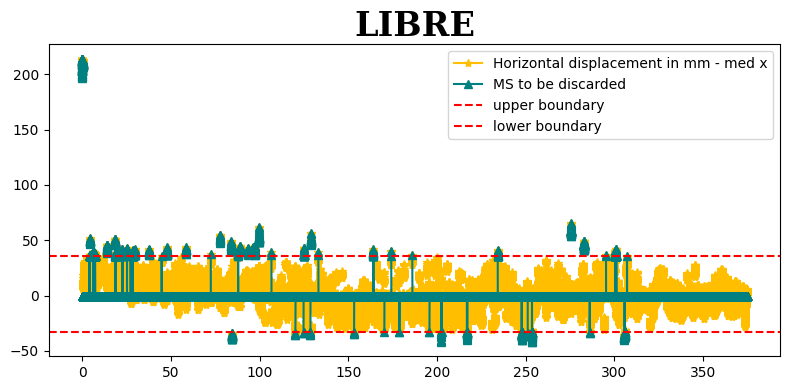

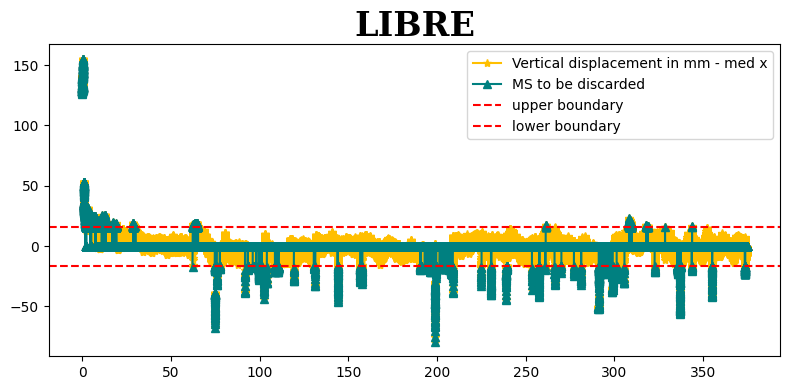

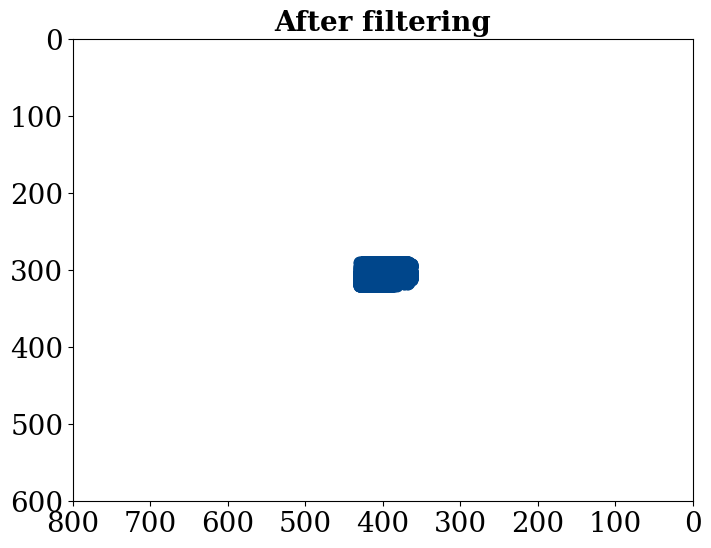

In [32]:

# First, we create a deep copy of the original coordinate data to avoid altering the original data.
coor_data_LIBRE_1 = copy.deepcopy(coor_data_LIBRE)

# Then, we calculate the statistics (such as median, quartiles, etc.) for the gaze data.
stats_dict = cal_stats(coor_data_LIBRE_1)

# Print the calculated statistics (e.g., median, Q25, Q75, etc.)
print(stats_dict)

# Now, we calculate the Interquartile Range (IQR) for both the x and y coordinates.
x_IQR = stats_dict['x_q75'] - stats_dict['x_q25']
y_IQR = stats_dict['y_q75'] - stats_dict['y_q25']

# Using the IQR, we calculate the boundaries for filtering out extreme gaze points.
# These boundaries are set using 1.5 times the IQR, a common threshold for outlier detection.
stand_x_lower = stats_dict['x_q25'] - 1.5 * x_IQR - stats_dict['x_median']
stand_x_upper = stats_dict['x_q75'] + 1.5 * x_IQR - stats_dict['x_median']

stand_y_lower = stats_dict['y_q25'] - 1.5 * y_IQR - stats_dict['y_median']
stand_y_upper = stats_dict['y_q75'] + 1.5 * y_IQR - stats_dict['y_median']

# Print the calculated upper and lower boundaries for both x and y coordinates.
print(f'stand_x_upper-{stand_x_upper} stand_x_lower-{stand_x_lower} stand_y_upper-{stand_y_upper} stand_y_lower-{stand_y_lower}')

# Next, we use the calculated thresholds to generate a mask (Disp_dict_LIBRE) that identifies which data points to keep or discard.
Disp_dict_LIBRE = cal_mask(coor_data_LIBRE_1, stand_x_upper, stand_x_lower,
                           stand_y_upper, stand_y_lower)

# We then plot the x and y coordinates with the mask applied, showing the filtered data.
plot_x_y_coord(Disp_dict_LIBRE, metadata, duration=None, start_sample=0, seq_name='LIBRE')

# Finally, we filter the data based on the generated mask, and separate the coordinates into those that are preserved and discarded.
filtered_coor_data_LIBRE, Preserve_mask, Discard_mask = filter_XY_coord(coor_data_LIBRE_1, Disp_dict_LIBRE, None)



You can play with the upper and lower boundary to filter the data as you need

{'x_mean': np.float64(397.06954140148815), 'x_median': np.float64(395.5), 'x_std': np.float64(13.955737401446955), 'x_min': np.float64(353.3999938964844), 'x_max': np.float64(609.7999877929688), 'x_q25': np.float64(388.2999877929688), 'x_q75': np.float64(405.2999877929688), 'y_mean': np.float64(305.2710657401416), 'y_median': np.float64(305.29998779296875), 'y_std': np.float64(9.855362153300605), 'y_min': np.float64(225.8000030517578), 'y_max': np.float64(460.7000122070313), 'y_q25': np.float64(301.0), 'y_q75': np.float64(309.0)}
stand_x_upper-40 stand_x_lower--40 stand_y_upper-40 stand_y_lower--40
X_coord [        nan         nan         nan ... 398.8999939 398.5
 398.6000061]
Y_coord [         nan          nan          nan ... 302.1000061  301.79998779
 300.1000061 ]
After cleaning nan, eminating data affected by blinking,            and preserving the fixation 
The length of X coordinate data: 374558
The length of Y coordinate data: 374558


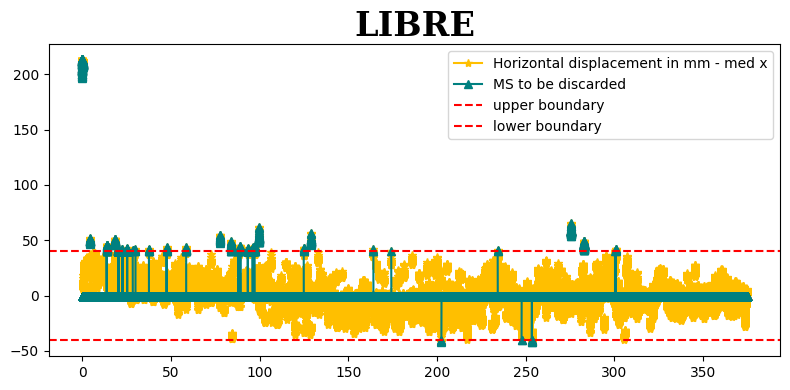

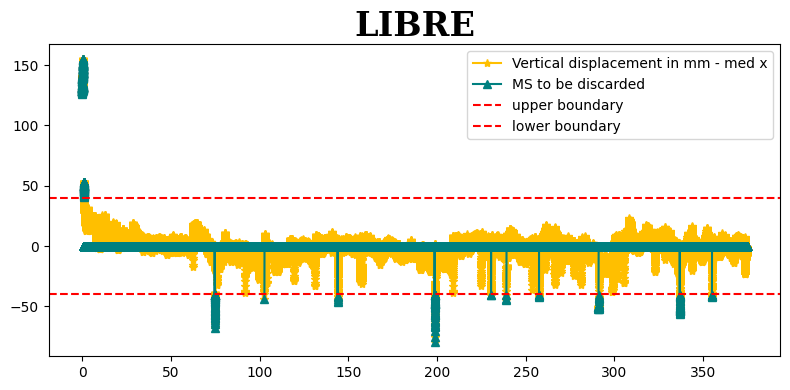

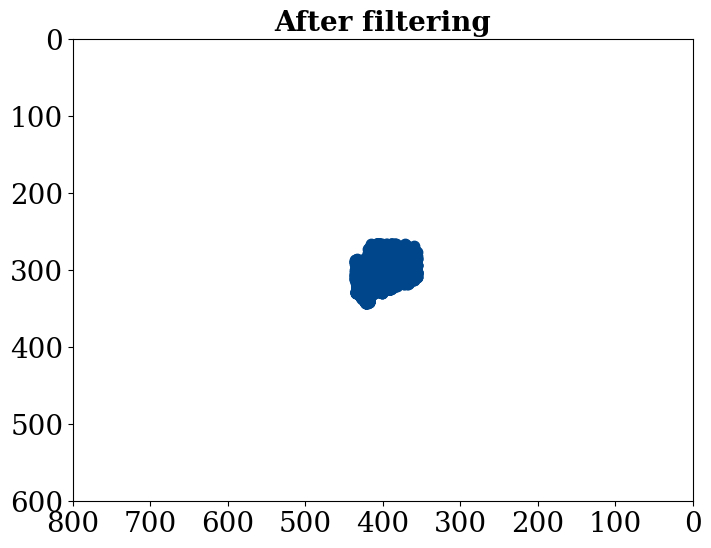

In [33]:
coor_data_LIBRE_1 = copy.deepcopy(coor_data_LIBRE)
stats_dict = cal_stats(coor_data_LIBRE_1)
print(stats_dict)

# You can play with the upper and lower boundary to filter the data as you need
stand_x_upper=40
stand_x_lower=-40
stand_y_upper=40
stand_y_lower=-40
print(f'stand_x_upper-{stand_x_upper} stand_x_lower-{stand_x_lower} stand_y_upper-{stand_y_upper} stand_y_lower-{stand_y_lower}')

Disp_dict_LIBRE = cal_mask(coor_data_LIBRE_1, stand_x_upper, stand_x_lower,
                           stand_y_upper, stand_y_lower)
plot_x_y_coord(Disp_dict_LIBRE, metadata, duration=None, start_sample=0, seq_name='LIBRE')
filtered_coor_data_LIBRE, Preserve_mask, Discard_mask = filter_XY_coord(coor_data_LIBRE_1, Disp_dict_LIBRE, None)


You can compare the preserved data with the original data.

👉 Simply run the code cell below to visualize the difference between the two datasets.

if same 0         False
1         False
2         False
3         False
4         False
          ...  
374553     True
374554     True
374555     True
374556     True
374557     True
Name: x_coordinate, Length: 374558, dtype: bool


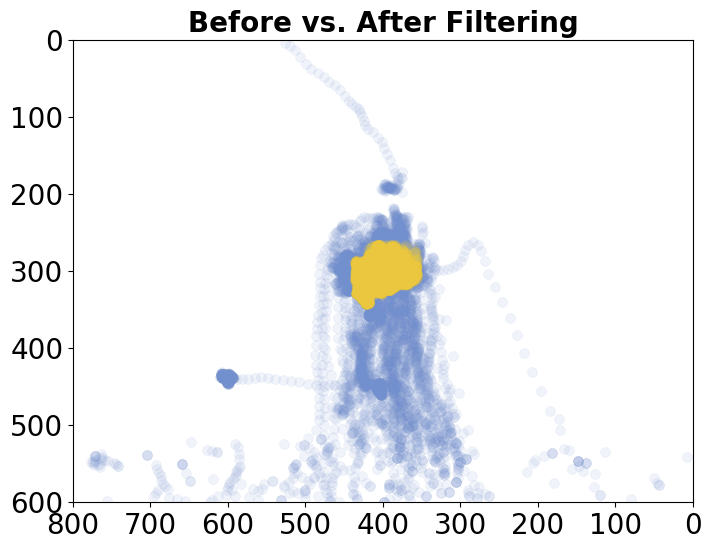

In [34]:
def visualization_func(fig_title, filtered_coor_data_LIBRE):
    from matplotlib.font_manager import FontProperties
    title_font = FontProperties(family='DejaVu Sans', size=20, weight='bold')
    axis_font = FontProperties(family='DejaVu Sans', size=20)

    fig, ax= plt.subplots(figsize=(8, 6))
    plt.title(fig_title, fontproperties=title_font)


    coor_data_LIBRE_vis = copy.deepcopy(coor_data_LIBRE)
    X_coord_1 = coor_data_LIBRE_raw['x_coordinate']
    Y_coord_1 = coor_data_LIBRE_raw['y_coordinate']


    plt.scatter(X_coord_1, Y_coord_1, s=50, c='#728FCE', alpha=0.1, edgecolors='#728FCE', linewidth=0.5)

    X_coord = filtered_coor_data_LIBRE['x_coordinate']
    Y_coord = filtered_coor_data_LIBRE['y_coordinate']
    print(F"if same {X_coord_1 == X_coord}")

    plt.scatter(X_coord, Y_coord, s=50, c='#f4d03f', alpha=0.1, edgecolors='#f4d03f', linewidth=0.5)  # Larger points


    plt.tick_params(axis='x', labelsize=14)
    plt.tick_params(axis='y', labelsize=14)
    plt.xlim((0, 800))
    plt.ylim((0, 600))

    for label in plt.gca().get_xticklabels():
        label.set_fontproperties(axis_font)

    for label in plt.gca().get_yticklabels():
        label.set_fontproperties(axis_font)
    # Reverse the direction of the Y-axis
    plt.gca().invert_yaxis()
    plt.gca().invert_xaxis()


# Visualization of filtered coor data LIBRE
visualization_func(fig_title='Before vs. After Filtering',
                   filtered_coor_data_LIBRE=filtered_coor_data_LIBRE)



# Step 6: Investigate the statistics of eye movement events across different subjects
Eye movement events such as blinks, saccades, and fixations provide valuable information about gaze behavior and data quality. By analyzing these events across different subjects, we can assess the consistency and reliability of the recorded data.


In this exercise, you will analyze the durations of different types of eye movements (e.g., blinks, saccades, and fixations) for different subjects. Your goal is to calculate the total time spent on each type of eye movement, how many times each event occurs, and derive statistical information about the duration of these events.

Steps:

1.	Event Occurrences (`'times'`):

  •	For each type of eye movement (blinks, saccades, or fixations), count how many times the event occurred.

  •	For example, you might find that a subject blinked 100 times, made 200 saccades, and had 50 fixations.


2.	Total Duration (`'total_duration'`):

  •	Calculate the total duration of each type of eye movement across the entire dataset.

  •	For example, if a subject blinked 100 times and each blink lasted, on average, 200 ms, the total duration of blinks for that subject would be the sum of all blink durations (100 * 200 ms).

3.	Individual Event Duration:

  •	For each occurrence of a specific event (e.g., each blink, saccade, or fixation), calculate its duration by subtracting the start time from the end time of the event.

  •	Example: If a blink starts at 0.5 seconds and ends at 0.7 seconds, the duration of that blink is 0.2 seconds.

4.	Statistical Analysis:

  •	After calculating the duration for each individual event, summarize the durations for each type of eye movement using these statistics:

  •	Mean Duration: The average duration across all occurrences of the event. This helps to understand the typical length of the eye movement.

  •	Median Duration: The middle value of the durations when they are sorted in ascending order. This is useful to understand the “typical” duration without being affected by extreme values.

  •	Standard Deviation (std): A measure of how spread out the durations are. A high standard deviation means the event durations vary a lot, while a low standard deviation means they are more consistent.

  •	Minimum Duration: The shortest duration recorded for an event.

  •	Maximum Duration: The longest duration recorded for an event.



 This analysis will help you understand how the eye tracking data is distributed and identify patterns or outliers.




## 6.1 Statistics calculation

In [35]:
# Simply run the cell
# Here we take T1w data as example: T_idx=1,
# and we load all the subjects: from Subject001 to Subject004

T_idx = 1
recording_list = []
for subject_idx in range(1,5):
    print(f'Load recording for subject {subject_idx}...')
    if T_idx == 1:
        mode = 'T1'
    else:
        mode = 'T2'


    BIDS_PATH = Path("./data/")  # file within a subdirectory
    FILE_NAME = f"sub00{subject_idx}_T{T_idx}"


    tsv_name = f"{FILE_NAME}.tsv.gz"

    recording_file = BIDS_PATH / tsv_name
    print(f'recording_file: {recording_file}')

    recording = pd.read_csv(
        recording_file,
    #     sep=r"\s+",
        sep="\t",
        na_values="n/a",
    )

    # Duration setting according to the MRI sequence info
    if  subject_idx == 1:
        T1_LIBRE = 374.558
        T2_LIBRE = 650.185
    elif subject_idx == 2:
        T1_LIBRE = 374.380
        T2_LIBRE = 650.185
    elif subject_idx == 3:
        T1_LIBRE = 334.237
        T2_LIBRE = 650.1925
    else:
        T1_LIBRE = 374.565
        T2_LIBRE = 650.1875

    if T_idx == 1:
        print(f"The length of T1_LIBRE Subject{subject_idx} should be: {T1_LIBRE}")
    else:
        print(f"The length of T2_LIBRE Subject{subject_idx} should be: {T2_LIBRE}")

    coor_recording = recording
    start_margin = int(0.0)
    if mode == 'T1':
        print(f'mode: {mode}')
        T1_LIBRE_sample = T1_LIBRE*metadata['SamplingFrequency']

    else:
        print(f'mode: {mode}')
        T2_LIBRE_sample = T2_LIBRE*metadata['SamplingFrequency']


    if mode == 'T1':
        coor_recording_LIBRE = coor_recording[start_margin:int(T1_LIBRE_sample)]
    else:
        coor_recording_LIBRE = coor_recording[start_margin:int(T2_LIBRE_sample)]
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_saccade': 'saccade'})
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_fixation': 'fixation'})
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_blink': 'blink'})
    recording_list.append(coor_recording_LIBRE)

Load recording for subject 1...
recording_file: data/sub001_T1.tsv.gz
The length of T1_LIBRE Subject1 should be: 374.558
mode: T1
Load recording for subject 2...
recording_file: data/sub002_T1.tsv.gz
The length of T1_LIBRE Subject2 should be: 374.38
mode: T1
Load recording for subject 3...
recording_file: data/sub003_T1.tsv.gz
The length of T1_LIBRE Subject3 should be: 334.237
mode: T1
Load recording for subject 4...
recording_file: data/sub004_T1.tsv.gz
The length of T1_LIBRE Subject4 should be: 374.565
mode: T1


Now I have stored the T1w data from subject1 to subject4 into a list: `recording_list`.


In [36]:
print(f'len of recording_list: {len(recording_list)}')
print('check Subject 4')
recording_list[3]

len of recording_list: 4
check Subject 4


,Unnamed: 0,eye1_x_coordinate,eye1_y_coordinate,eye1_pupil_size,eye1_pupil_x_coordinate,eye1_pupil_y_coordinate,eye1_href_x_coordinate,eye1_href_y_coordinate,fast_raw_x_velocity,screen_ppdeg_x_coordinate,screen_ppdeg_y_coordinate,timestamp,fixation,saccade,blink
0,0,454.200012,412.000000,2514.0,-2981.0,-3153.0,535.0,1105.0,4.591214e-41,26.6,26.6,8431141,0,0,0
1,1,454.299988,410.299988,2513.0,-2981.0,-3165.0,535.0,1089.0,4.591214e-41,26.6,26.6,8431142,0,0,0
2,2,454.200012,406.100006,2519.0,-2983.0,-3196.0,535.0,1047.0,4.591214e-41,26.6,26.6,8431143,0,0,0
3,3,454.200012,401.899994,2526.0,-2985.0,-3227.0,535.0,1006.0,4.591214e-41,26.6,26.6,8431144,0,0,0
4,4,454.200012,401.899994,2526.0,-2985.0,-3227.0,535.0,1006.0,4.591214e-41,26.6,26.6,8431145,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374560,374560,412.600006,331.299988,2246.0,-3406.0,-3712.0,125.0,309.0,-3.822000e+03,26.5,26.5,8805701,0,1,0
374561,374561,411.299988,330.200012,2244.0,-3419.0,-3719.0,111.0,298.0,-3.822000e+03,26.5,26.5,8805702,0,1,0
374562,374562,410.200012,327.500000,2244.0,-3430.0,-3738.0,101.0,271.0,-3.822000e+03,26.5,26.5,8805703,0,1,0
374563,374563,410.600006,325.399994,2245.0,-3427.0,-3754.0,104.0,251.0,-3.822000e+03,26.5,26.5,8805704,0,1,0


In [37]:
# -------------cut-----------------

# Identify start and end indices of each event
def identify_start_end_event(df, events):
    event_dict = {}
    # Detect the start and end of each saccade
    df['saccade_shift'] = df['saccade'].shift(1, fill_value=0)
    df['saccade_change'] = df['saccade'] - df['saccade_shift']

    # Detect the start and end of each fixation
    df['fixation_shift'] = df['fixation'].shift(1, fill_value=0)
    df['fixation_change'] = df['fixation'] - df['fixation_shift']

    # Detect the start and end of each blink
    df['blink_shift'] = df['blink'].shift(1, fill_value=0)
    df['blink_change'] = df['blink'] - df['blink_shift']

    for event in events:
        event_change = event+'_change'

        event_starts = df.index[df[event_change] == 1].tolist()
        event_ends = df.index[df[event_change] == -1].tolist()

        # If the last row is part of a event, add it as an end
        if df[event].iloc[-1] == 1:
            event_ends.append(df.index[-1])

        # Calculate number of events
        num_events = len(event_starts)

        # Calculate duration for each event
        event_durations = []
        for start, end in zip(event_starts, event_ends):
            # Duration in milliseconds or based on the timestamp difference
            duration = end - start + 1  # If in milliseconds
            # If you have a timestamp column (e.g., in ms), you could calculate it as:
            # duration = df['timestamp'].iloc[end] - df['timestamp'].iloc[start]
            event_durations.append(duration)

        # Display results
        num_event_str = 'num_'+event
        event_dict[num_event_str] = num_events
        event_duration_str = event+'_durations'
        event_dict[event_duration_str] = event_durations

    return event_dict



def cal_event_stat(event_duration):

    event_stat_dict={}
    event_stat_dict['mean_duration'] = np.mean(event_duration)
    event_stat_dict['median_duration'] = np.median(event_duration)
    event_stat_dict['std_duration'] = np.std(event_duration)
    event_stat_dict['min_duration'] = int(np.min(event_duration))
    event_stat_dict['max_duration'] = int(np.max(event_duration))
    event_stat_dict['total_duration'] = sum(event_duration)
    event_stat_dict['times'] = len(event_duration)

    return event_stat_dict



events = ['saccade', 'fixation', 'blink']
subject_event_dict = []
for idx in range(4):
    df = copy.deepcopy(recording_list[idx])

    event_dict = identify_start_end_event(df, events)
    subject_event_dict.append(event_dict)



subject_blink_stat = []
subject_saccade_stat = []
subject_fixation_stat = []
for idx in range(4):
    event_dict = subject_event_dict[idx]

    blink_stat = cal_event_stat(event_dict['blink_durations'])
    subject_blink_stat.append(blink_stat)

    saccade_stat = cal_event_stat(event_dict['saccade_durations'])
    subject_saccade_stat.append(saccade_stat)

    fixation_stat = cal_event_stat(event_dict['fixation_durations'])
    subject_fixation_stat.append(fixation_stat)

# ---------end---------------

In [57]:
# 🔍 Your turn!
# 👉 For each subject, calculate the statistics of eye movement durations.
# You should compute and store the results separately for:
# - blinks → subject_blink_stat
# - saccades → subject_saccade_stat
# - fixations → subject_fixation_stat


# subject_blink_stat = ?
# subject_saccade_stat = ?
# subject_fixation_stat = ?

✅ Expected Output Format

Your result should be saved in a list called subject_[event]_stat, where each item in the list is a dictionary representing one subject.

Each dictionary should contain the following statistics for the event(blink/saccade/fixation) durations:

•	'mean_duration': The average duration of the event

•	'median_duration': The median duration (middle value)

•	'std_duration': The standard deviation, showing the variability in the event durations

•	'min_duration': The shortest event duration

•	'max_duration': The longest event duration

•	'total_duration': The total time spent blinking

•	'times': The number of occurrence of the event.

take `subject_blink_stat` as example, similarly to saccade and fixation.

```
subject_blink_stat =
[{'mean_duration': 307.8709677419355,
  'median_duration': 298.0,
  'std_duration': 102.14434503017836,
  'min_duration': 136,
  'max_duration': 612,
  'total_duration': 9544,
  'times': 31},
 {'mean_duration': 193.7906976744186,
  'median_duration': 191.0,
  'std_duration': 53.478775681109795,
  'min_duration': 84,
  'max_duration': 366,
  'total_duration': 8333,
  'times': 43},
 {'mean_duration': 279.44444444444446,
  'median_duration': 257.0,
  'std_duration': 95.55863782404288,
  'min_duration': 82,
  'max_duration': 643,
  'total_duration': 17605,
  'times': 63},
 {'mean_duration': 570.566265060241,
  'median_duration': 222.5,
  'std_duration': 963.5041179818476,
  'min_duration': 2,
  'max_duration': 7006,
  'total_duration': 94714,
  'times': 166}]
```



In [54]:
save_event_stat = False

if save_event_stat:
  import json

  with open("subject_fixation_stat.json", "w") as f:
      json.dump(subject_fixation_stat, f)


  with open("subject_saccade_stat.json", "w") as f:
      json.dump(subject_saccade_stat, f)

  with open("subject_blink_stat.json", "w") as f:
      json.dump(subject_blink_stat, f)

save_subject_event_dict = True
if save_subject_event_dict:
  import json

  with open("subject_event_dict.json", "w") as f:
      json.dump(subject_event_dict, f)

In [46]:
load_event_stat = False
if load_event_stat:
  import json

  # Load the JSON file
  with open("subject_fixation_stat.json", "r") as f:
      subject_fixation_stat = json.load(f)
  print('subject_fixation_stat')
  print(subject_fixation_stat)

  with open("subject_saccade_stat.json", "r") as f:
      subject_saccade_stat = json.load(f)
  print('subject_saccade_stat')
  print(subject_saccade_stat)

  with open("subject_blink_stat.json", "r") as f:
      subject_blink_stat = json.load(f)
  print('subject_blink_stat')
  print(subject_blink_stat)




subject_fixation_stat
[{'mean_duration': 485.3278463648834, 'median_duration': 247.0, 'std_duration': 623.9966482850247, 'min_duration': 22, 'max_duration': 4157, 'total_duration': 353804, 'times': 729}, {'mean_duration': 672.0169811320754, 'median_duration': 491.5, 'std_duration': 594.362456671281, 'min_duration': 17, 'max_duration': 5003, 'total_duration': 356169, 'times': 530}, {'mean_duration': 417.9804195804196, 'median_duration': 246.0, 'std_duration': 466.94418247439074, 'min_duration': 24, 'max_duration': 3348, 'total_duration': 298856, 'times': 715}, {'mean_duration': 128.8170276325616, 'median_duration': 92.0, 'std_duration': 117.27843003164334, 'min_duration': 9, 'max_duration': 1012, 'total_duration': 172486, 'times': 1339}]
subject_saccade_stat
[{'mean_duration': 30.498626373626372, 'median_duration': 17.0, 'std_duration': 63.4662885186532, 'min_duration': 6, 'max_duration': 612, 'total_duration': 22203, 'times': 728}, {'mean_duration': 36.3062381852552, 'median_duration':

## 6.2 Violin Plot

A Violin Plot is a useful tool for visualizing event statistics.

A violin plot combines the strengths of both a box plot and a density plot, making it an excellent choice for visualizing distributions of data. It not only shows key summary statistics (like median and interquartile range), but also the full distribution shape — providing deeper insight into the variability of the data.

In this section, you’ll explore the distribution of eye movement durations (blinks, saccades, fixations) across four subjects using violin plots.

👉 We’ve preprocessed the data for you. Your task here is simple:

•	Run the provided code cell

•	Load the saved statistics

•	Observe and interpret the violin plots

In [47]:
def voilinplot(subject_event_dict, event,color='skyblue'):
    sub_num = len(subject_event_dict)
    event_duration_list=[]
    for idx in range(sub_num):
        event_durations_str = f'{event}_durations'
        event_duration_list.append(subject_event_dict[idx][event_durations_str])

    df = pd.DataFrame({
        'Duration': [duration for sublist in event_duration_list for duration in sublist],
        'Subject': [f'Subject {i+1}' for i, sublist in enumerate(event_duration_list) for _ in sublist]
    })

    plt.figure(figsize=(6, 5))
    sns.violinplot(data=df, x='Subject', y='Duration', color=color)
    plt.title(f"Violin Plot of {event} Durations Across Subjects")
    plt.ylabel("Duration (ms)")
    plt.xlabel("Subject")
    plt.show()



subject_event_dict
<class 'list'>


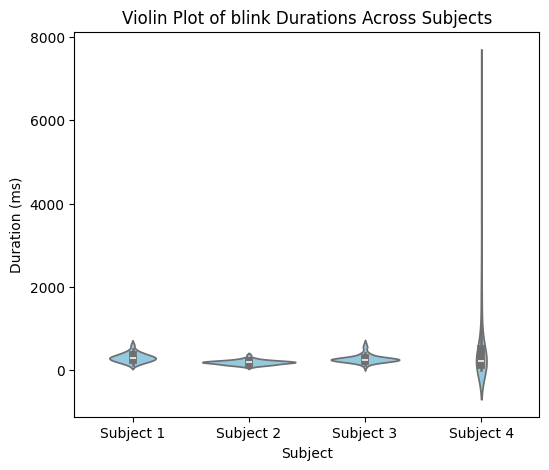

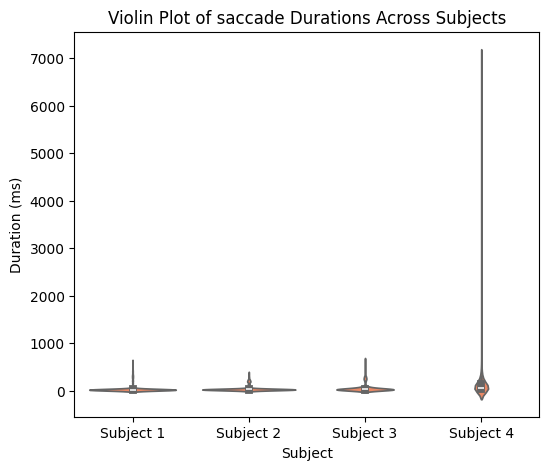

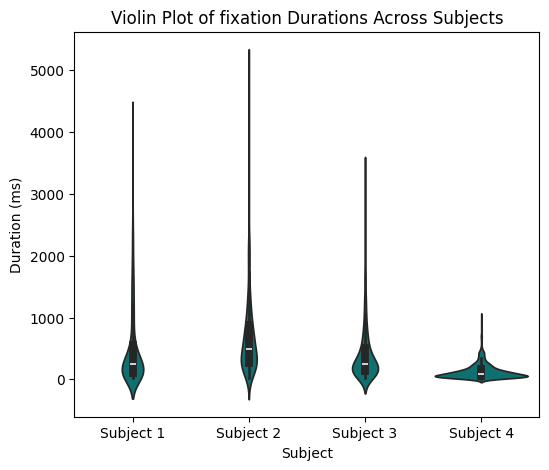

In [55]:
load_subject_event_dict = True
if load_subject_event_dict:
  import json

  # Load the JSON file
  with open("subject_event_dict.json", "r") as f:
      subject_event_dict = json.load(f)
  print('subject_event_dict')
  print(type(subject_event_dict))

voilinplot(subject_event_dict, event='blink', color='skyblue')
voilinplot(subject_event_dict, event='saccade',color='coral')
voilinplot(subject_event_dict, event='fixation',color='teal')

## 6.3 Statistics Test

Statistical tests, such as the Mann-Whitney U Test, t-Test, and Kolmogorov-Smirnov Test are used to compare statistics to determine whether differences between groups or conditions are significant or due to random variation. Without statistical tests, comparisons might rely on subjective observations or visual inspection, which are prone to bias. Statistical tests provide quantifiable and reproducible evidence to support conclusions.

- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples.
It is particularly useful when comparing groups where the data may not meet the assumptions required by parametric tests like the t-test.

- T-test requires normally distributed data and equal variances, which may not hold true for eye movement statistics. Violating these assumptions could lead to misleading results.

- Kolmogorov-Smirnov Test compares entire distributions but lacks the sensitivity of the Mann-Whitney U test for detecting location shifts (differences in medians).


Eye-tracking event statistics (e.g., blink counts, fixation durations) may not follow normal distributions due to inter-subject variability or artifacts. The Mann-Whitney U test allows robust comparison of these statistics between groups or conditions without requiring strict assumptions about the data.


In [62]:
def mann_whitney_u_stats(subject_event_dict, event):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    from scipy.stats import mannwhitneyu
    sub_num = len(subject_event_dict)
    event_duration_list=[]
    for idx in range(sub_num):
        event_durations_str = f'{event}_durations'
        event_duration_list.append(subject_event_dict[idx][event_durations_str])

    # Prepare data for Seaborn
    df = pd.DataFrame({
        'Duration': [duration for sublist in event_duration_list for duration in sublist],
        'Subject': [f'subjects {i+1}' for i, sublist in enumerate(event_duration_list) for _ in sublist]
    })

    print(f"Pairwise Mann-Whitney U test results for {event} durations:")
    for i in range(sub_num):
        for j in range(i + 1, sub_num):
            stat, p_value = mannwhitneyu(event_duration_list[i], event_duration_list[j], alternative='two-sided')
            print(f"Comparison between {f'subjects {i+1}'} and {f'subjects {j+1}'}: U = {stat}, p = {p_value:.4f}")


def kruskal_wallis_stats(subject_event_dict, event):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import itertools
    from scipy.stats import kruskal, mannwhitneyu
    sub_num = len(subject_event_dict)
    event_duration_list=[]
    for idx in range(sub_num):
        event_durations_str = f'{event}_durations'
        event_duration_list.append(subject_event_dict[idx][event_durations_str])


    kruskal_result = kruskal(*event_duration_list)
    print(f"Kruskal–Wallis for {event} durations: H = {kruskal_result.statistic:.4f}, p = {kruskal_result.pvalue:.4e}")

    if kruskal_result.pvalue < 0.05:
        print("\n✅ Significant differences found — running pairwise Mann–Whitney U tests...\n")

        # 👯 Pairwise Mann–Whitney U tests
        subject_pairs = list(itertools.combinations(range(len(event_duration_list)), 2))
        p_values = []

        for i, j in subject_pairs:
            u_stat, p_val = mannwhitneyu(event_duration_list[i], event_duration_list[j], alternative='two-sided')
            p_values.append(p_val)
            print(f"Comparison between subjects {i+1} and {j+1}: U = {u_stat:.1f}, p = {p_val:.4e}")

        # 🧠 Bonferroni correction
        corrected_alpha = 0.05 / len(p_values)
        print(f"\nBonferroni corrected alpha = {corrected_alpha:.4f}")
        for (i, j), p in zip(subject_pairs, p_values):
            result = "✅ Significant" if p < corrected_alpha else "❌ Not Significant"
            print(f"Subjects {i+1} vs {j+1}: p = {p:.4e} → {result}")
    else:
        print("❌ No significant difference found across subjects.")






In [63]:
# mann_whitney_u_stats(subject_event_dict,'saccade')
kruskal_wallis_stats(subject_event_dict, 'saccade')

Kruskal–Wallis for saccade durations: H = 879.6022, p = 2.3518e-190

✅ Significant differences found — running pairwise Mann–Whitney U tests...

Comparison between subjects 1 and 2: U = 126157.0, p = 1.3524e-25
Comparison between subjects 1 and 3: U = 162432.0, p = 5.9306e-35
Comparison between subjects 1 and 4: U = 154110.5, p = 7.3345e-146
Comparison between subjects 2 and 3: U = 165390.0, p = 1.7631e-04
Comparison between subjects 2 and 4: U = 158977.5, p = 4.2815e-77
Comparison between subjects 3 and 4: U = 267041.5, p = 4.0668e-61

Bonferroni corrected alpha = 0.0083
Subjects 1 vs 2: p = 1.3524e-25 → ✅ Significant
Subjects 1 vs 3: p = 5.9306e-35 → ✅ Significant
Subjects 1 vs 4: p = 7.3345e-146 → ✅ Significant
Subjects 2 vs 3: p = 1.7631e-04 → ✅ Significant
Subjects 2 vs 4: p = 4.2815e-77 → ✅ Significant
Subjects 3 vs 4: p = 4.0668e-61 → ✅ Significant
